[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 9: z Transform

- initially authored by https://github.com/robhau
- double checked and adapted by https://github.com/fs446

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import tf2zpk

In [2]:
cur_fol = os.getcwd()
print(cur_fol)
sys.path.append(cur_fol + '/../')

/Users/fs446/git/signals-and-systems-exercises/z_system_analysis


In [3]:
from sig_sys_tools import plot_dtlti_analysis

### Transfer Function of a Discrete-Time LTI System

A simple, causal system is given by its transfer function in $z$ domain  
$$H(z) = \frac{1}{2} \cdot \frac{z-3}{z-\frac{3}{4}} = \frac{1}{2} \cdot \frac{1 - 3 z^{-1}}{1 - \frac{3}{4} z^{-1}}$$
with pole $z_{\infty}=\frac{3}{4}$, zero $z_0=3$ and gain factor $k=\frac{1}{2}$. Region of convergence follows from the pole and is thus $|z|>\frac{1}{3}$.
Let us set up this system first:

In [4]:
z0 = 3
zoo = 3/4
k = 1/2

### Frequency and Time Response

As next step, let us render the usual plots of the LTI system characteristics in time and frequency domain. For that we can use the convenient function

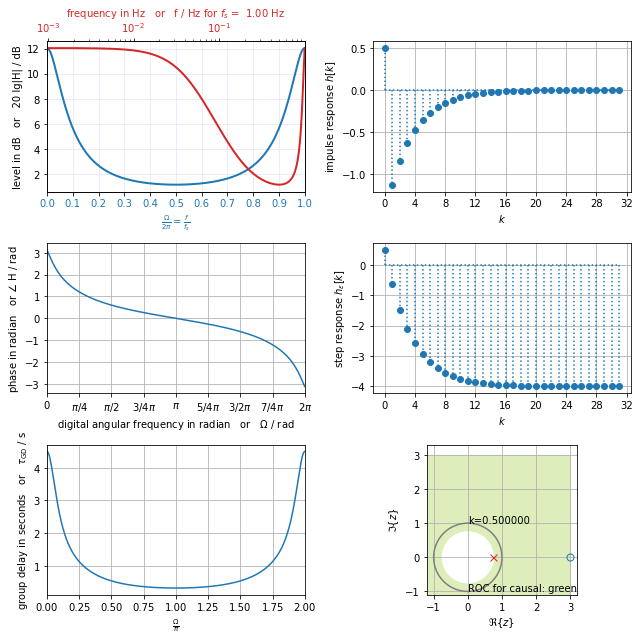

In [5]:
plot_dtlti_analysis(z0, zoo, k)

We see that this simple system has lowpass characteristics since the pole dominates the influence what is going on along the unit circle (i.e. where we evaluate the $z$-transfer function to get the frequency response of the system).

### 3D Surface Plot of the Transfer Function

We can further visualize $|H(z)|$ over the $z$ plane to get an impression why the pole actually is responsible for the observed lowpass characteristics. Please check the black circle which is $20 \log_{10} |H(z)|$ in dB for all $|z|=1$ (i.e. evaluation on the unit circle). The pole (high level, red color) and the zero (low level, blue color) is easily seen in the 3D plot below.

50.31531975697702 -61.22628004139165 34.034004740059615 35.73875747139498


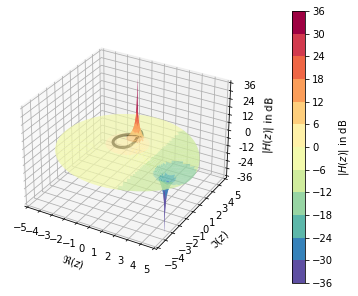

In [6]:
N = 2**9
m_z = np.linspace(1e-6, 5, N)
p_z = np.linspace(0, 2*np.pi, N)
magnitude_z, phase_z = np.meshgrid(m_z, p_z, sparse=False, indexing='xy')
z = magnitude_z*np.exp(1j*phase_z)
ejomega = np.exp(1j*phase_z)

H_z = k * (z - z0) / (z - zoo)
H_ejomega = k * (ejomega-z0) / (ejomega - zoo)

xa = 20*np.log10(np.abs(H_z))
xfta = 20*np.log10(np.abs(H_ejomega))
xa_max = np.max(xa)
xa_min = np.min(xa)
print(xa_max,
      xa_min,
      20*np.log10(xa_max),
      20*np.log10(np.abs(xa_min)))  # to check resolution of colormap/-bar

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
Ncol = (36+42)//6
col_tick = np.linspace(-36, 42, Ncol, endpoint=False)
cmap = mpl.cm.get_cmap('Spectral_r')
norm = mpl.colors.BoundaryNorm(col_tick, cmap.N)
surf = ax.plot_surface(magnitude_z*np.cos(phase_z),
                       magnitude_z*np.sin(phase_z),
                       xa,
                       cmap=cmap, norm=norm,
                       rstride=5, cstride=5, linewidth=0, alpha=1)
ax.plot3D(np.real(ejomega)[:, N//2], np.imag(ejomega)[:, N//2],
          xfta[:, N//2], 'k', lw=3, alpha=1)

cbar = fig.colorbar(surf, ax=ax, ticks=col_tick,
                    label=r'$|H(z)|$ in dB', pad=0.15)
# TBD: location='left' in newer matplotlib version
ax.set_xlabel(r'$\Re(z)$')
ax.set_ylabel(r'$\Im(z)$')
ax.set_zlabel(r'$|H(z)|$ in dB')
#ax.view_init(azim=-60, elev=30)
#print(ax.azim, ax.elev)
ax.set_xlim(-5, 5)
ax.set_xticks(np.arange(-5, 6, 1))
ax.set_ylim(-5, 5)
ax.set_yticks(np.arange(-5, 6, 1))
ax.set_zlim(-36, 36)
ax.set_zticks(np.arange(-36, 36+6, 6))
ax.set_zticklabels(['-36', ' ', '-24', ' ', '-12', ' ',
                   '0', ' ', '12', ' ', '24', ' ', '36'])
plt.savefig('ztransferfunction_pzmaps3D.pdf')

Question: What frequency response do we expect when we shift the zero to `z0 = 4/3`, i.e. closer to the unit circle. Can we explain this by interpreting the influence of the pole and the zero with respect to the unit circle.

Question: Can we use the inverted system for any practical purpose? Why (not)?

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.